In [17]:
import pandas as pd
import numpy as np

In [18]:
data = pd.read_csv('/kaggle/input/datasetx/train (1).csv')
data.head()

,request_src,timestamp,method,dest_path,http_type,status,bytes
0,199.72.81.55,01/Jul/1995:00:00:01 -0400,GET,/history/apollo/,HTTP/1.0,200,6245
1,unicomp6.unicomp.net,01/Jul/1995:00:00:06 -0400,GET,/shuttle/countdown/,HTTP/1.0,200,3985
2,199.120.110.21,01/Jul/1995:00:00:09 -0400,GET,/shuttle/missions/sts-73/mission-sts-73.html,HTTP/1.0,200,4085
3,burger.letters.com,01/Jul/1995:00:00:11 -0400,GET,/shuttle/countdown/liftoff.html,HTTP/1.0,304,0
4,199.120.110.21,01/Jul/1995:00:00:11 -0400,GET,/shuttle/missions/sts-73/sts-73-patch-small.gif,HTTP/1.0,200,4179


In [19]:
data = pd.read_csv('/kaggle/input/datasetx/test (1).csv')
data.head()

,request_src,timestamp,method,dest_path,http_type,status,bytes
0,ix-mia1-02.ix.netcom.com,23/Aug/1995:00:00:00 -0400,GET,/ksc.html,HTTP/1.0,200,7087
1,internet-gw.watson.ibm.com,23/Aug/1995:00:00:05 -0400,GET,/history/apollo/pad-abort-test-2/pad-abort-tes...,HTTP/1.0,200,1292
2,ix-mia1-02.ix.netcom.com,23/Aug/1995:00:00:06 -0400,GET,/images/ksclogo-medium.gif,HTTP/1.0,200,5866
3,internet-gw.watson.ibm.com,23/Aug/1995:00:00:08 -0400,GET,/history/apollo/pad-abort-test-2/pad-abort-tes...,HTTP/1.0,200,1625
4,internet-gw.watson.ibm.com,23/Aug/1995:00:00:10 -0400,GET,/history/apollo/pad-abort-test-2/pad-abort-tes...,HTTP/1.0,404,0


In [20]:
data['request_src'].value_counts()

request_src
edams.ksc.nasa.gov      2496
163.206.89.4            2313
beta.xerox.com          1869
piweba4y.prodigy.com    1803
piweba3y.prodigy.com    1586
                        ... 
mcopelan.cc.wvu.edu        1
eamps1.harvard.edu         1
bob.ocis.olemiss.edu       1
139.86.144.59              1
filsun07.nada.kth.se       1
Name: count, Length: 28976, dtype: int64

In [21]:
data['method'].value_counts()

method
GET     525217
HEAD      1388
POST        41
Name: count, dtype: int64

In [22]:
data['dest_path'].value_counts()

dest_path
/images/NASA-logosmall.gif           37671
/images/KSC-logosmall.gif            24885
/images/MOSAIC-logosmall.gif         23558
/images/USA-logosmall.gif            23404
/images/WORLD-logosmall.gif          23167
                                     ...  
/cgi-bin/imagemap/index69?622,259        1
/cgi-bin/imagemap/index69?258,170        1
/cgi-bin/imagemap/index69?260,161        1
/cgi-bin/imagemap/index69?330,153        1
/cgi-bin/imagemap/index69?350,167        1
Name: count, Length: 8910, dtype: int64

In [23]:
df = data.copy()
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    format="%d/%b/%Y:%H:%M:%S %z", errors='coerce' # Added errors='coerce' to handle parsing issues
)

df = df.set_index("timestamp")

df.head()

,request_src,method,dest_path,http_type,status,bytes
timestamp,,,,,,
1995-08-23 00:00:00-04:00,ix-mia1-02.ix.netcom.com,GET,/ksc.html,HTTP/1.0,200,7087
1995-08-23 00:00:05-04:00,internet-gw.watson.ibm.com,GET,/history/apollo/pad-abort-test-2/pad-abort-tes...,HTTP/1.0,200,1292
1995-08-23 00:00:06-04:00,ix-mia1-02.ix.netcom.com,GET,/images/ksclogo-medium.gif,HTTP/1.0,200,5866
1995-08-23 00:00:08-04:00,internet-gw.watson.ibm.com,GET,/history/apollo/pad-abort-test-2/pad-abort-tes...,HTTP/1.0,200,1625
1995-08-23 00:00:10-04:00,internet-gw.watson.ibm.com,GET,/history/apollo/pad-abort-test-2/pad-abort-tes...,HTTP/1.0,404,0


In [24]:
!pip install pmdarima

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima

df_raw = pd.read_csv('/kaggle/input/datasetx/train (1).csv', usecols=['timestamp', 'request_src'], engine='c')

time_format = "%d/%b/%Y:%H:%M:%S %z"
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'], format=time_format, cache=True)
df_raw.set_index('timestamp', inplace=True)

df_1m = df_raw['request_src'].resample('1min').count().tz_localize(None)

In [26]:
import pandas as pd

time_format = "%d/%b/%Y:%H:%M:%S %z"

df_train_raw = pd.read_csv('/kaggle/input/datasetx/test (1).csv')
df_train_raw['timestamp'] = pd.to_datetime(df_train_raw['timestamp'], format=time_format)
df_train_raw.set_index('timestamp', inplace=True)
train_series = df_train_raw['request_src'].resample('1min').count().fillna(0)

df_test_raw = pd.read_csv('/kaggle/input/datasetx/test (1).csv')
df_test_raw['timestamp'] = pd.to_datetime(df_test_raw['timestamp'], format=time_format)
df_test_raw.set_index('timestamp', inplace=True)
test_series = df_test_raw['request_src'].resample('1min').count().fillna(0)

df_1min = train_series
train = train_series
test = test_series

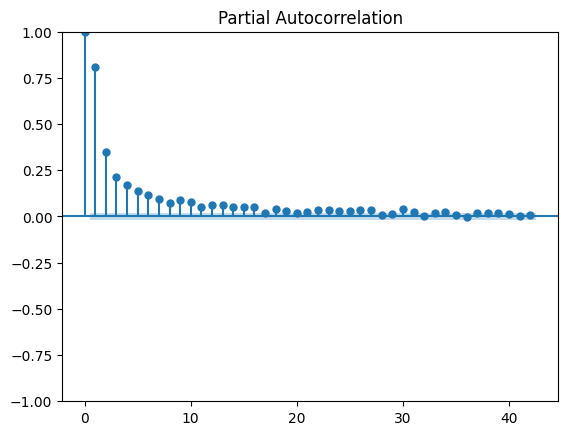

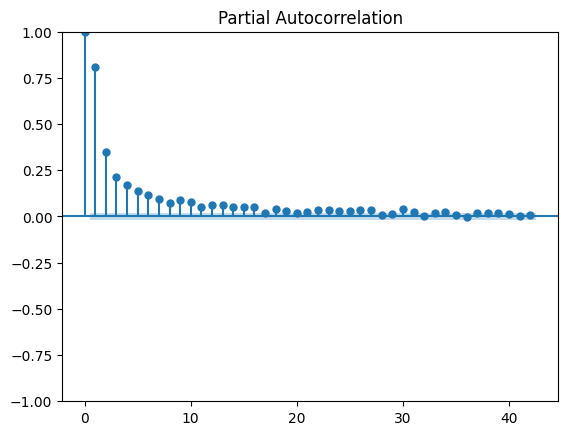

In [27]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plot_pacf(train)

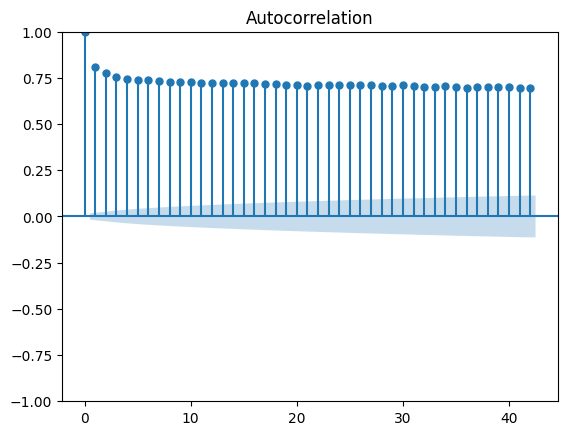

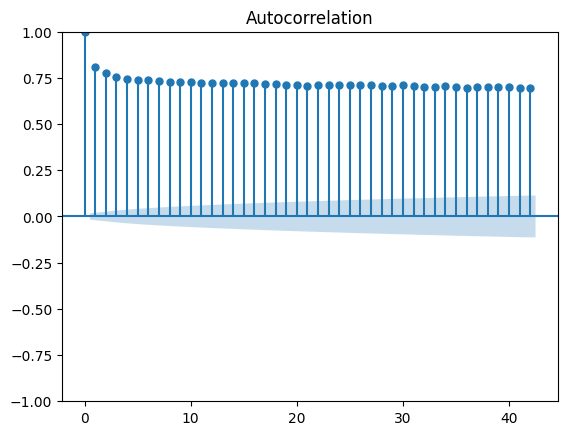

In [28]:
plot_acf(train)

In [29]:
results = {}
timeframes = {'1m': '1T', '5m': '5T', '15m': '15T'}

for label, freq in timeframes.items():

    data = df_raw['request_src'].resample(freq).count().tz_localize(None).tail(2000)

    m_val = 15 if label == '15m' else (5 if label == '5m' else 1)

    model = auto_arima(data,
                       seasonal=True, m=m_val,
                       start_p=1, start_q=1, max_p=7, max_q=7,
                       d=1, D=1, trace=True,
                       error_action='ignore', suppress_warnings=True)

    # Dự báo trên chính tập dữ liệu để xem độ khớp (In-sample forecast)
    forecast = model.predict_in_sample()
    results[label] = (data, forecast)


/tmp/ipykernel_55/2809892765.py:6: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  data = df_raw['request_src'].resample(freq).count().tz_localize(None).tail(2000)


Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16326.931, Time=0.67 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=17193.229, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16743.455, Time=0.26 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16353.596, Time=0.37 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=17191.231, Time=0.05 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=16316.848, Time=0.93 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=16572.493, Time=0.47 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=16310.097, Time=1.37 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=16501.897, Time=0.32 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=16310.286, Time=1.87 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=16311.255, Time=3.04 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16309.374, Time=3.12 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=16307.746, Time=1.55 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=16331.962, Time=0.47 sec
 ARIMA(1,1,3)(0,0,0

/tmp/ipykernel_55/2809892765.py:6: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  data = df_raw['request_src'].resample(freq).count().tz_localize(None).tail(2000)


Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,1,1)[5]             : AIC=inf, Time=2.37 sec
 ARIMA(0,1,0)(0,1,0)[5]             : AIC=22724.075, Time=0.07 sec
 ARIMA(1,1,0)(1,1,0)[5]             : AIC=21931.929, Time=0.52 sec
 ARIMA(0,1,1)(0,1,1)[5]             : AIC=inf, Time=0.89 sec
 ARIMA(1,1,0)(0,1,0)[5]             : AIC=22460.271, Time=0.09 sec
 ARIMA(1,1,0)(2,1,0)[5]             : AIC=21718.397, Time=1.07 sec
 ARIMA(1,1,0)(2,1,1)[5]             : AIC=inf, Time=3.06 sec
 ARIMA(1,1,0)(1,1,1)[5]             : AIC=inf, Time=1.58 sec
 ARIMA(0,1,0)(2,1,0)[5]             : AIC=22052.471, Time=0.32 sec
 ARIMA(2,1,0)(2,1,0)[5]             : AIC=21575.194, Time=1.21 sec
 ARIMA(2,1,0)(1,1,0)[5]             : AIC=21788.329, Time=0.92 sec
 ARIMA(2,1,0)(2,1,1)[5]             : AIC=inf, Time=3.72 sec
 ARIMA(2,1,0)(1,1,1)[5]             : AIC=inf, Time=2.21 sec
 ARIMA(3,1,0)(2,1,0)[5]             : AIC=21551.245, Time=1.58 sec
 ARIMA(3,1,0)(1,1,0)[5]             : AIC=21763.073, Ti

/tmp/ipykernel_55/2809892765.py:6: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  data = df_raw['request_src'].resample(freq).count().tz_localize(None).tail(2000)


Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,1,1)[15]             : AIC=inf, Time=12.08 sec
 ARIMA(0,1,0)(0,1,0)[15]             : AIC=25787.053, Time=0.10 sec
 ARIMA(1,1,0)(1,1,0)[15]             : AIC=25108.872, Time=1.57 sec
 ARIMA(0,1,1)(0,1,1)[15]             : AIC=inf, Time=4.72 sec
 ARIMA(1,1,0)(0,1,0)[15]             : AIC=25619.936, Time=0.13 sec
 ARIMA(1,1,0)(2,1,0)[15]             : AIC=24894.083, Time=4.24 sec
 ARIMA(1,1,0)(2,1,1)[15]             : AIC=inf, Time=22.49 sec
 ARIMA(1,1,0)(1,1,1)[15]             : AIC=inf, Time=6.49 sec
 ARIMA(0,1,0)(2,1,0)[15]             : AIC=25035.863, Time=3.02 sec
 ARIMA(2,1,0)(2,1,0)[15]             : AIC=24865.379, Time=4.85 sec
 ARIMA(2,1,0)(1,1,0)[15]             : AIC=25079.514, Time=2.72 sec
 ARIMA(2,1,0)(2,1,1)[15]             : AIC=inf, Time=26.35 sec
 ARIMA(2,1,0)(1,1,1)[15]             : AIC=inf, Time=9.68 sec
 ARIMA(3,1,0)(2,1,0)[15]             : AIC=24865.132, Time=6.56 sec
 ARIMA(3,1,0)(1,1,0)[15]             :

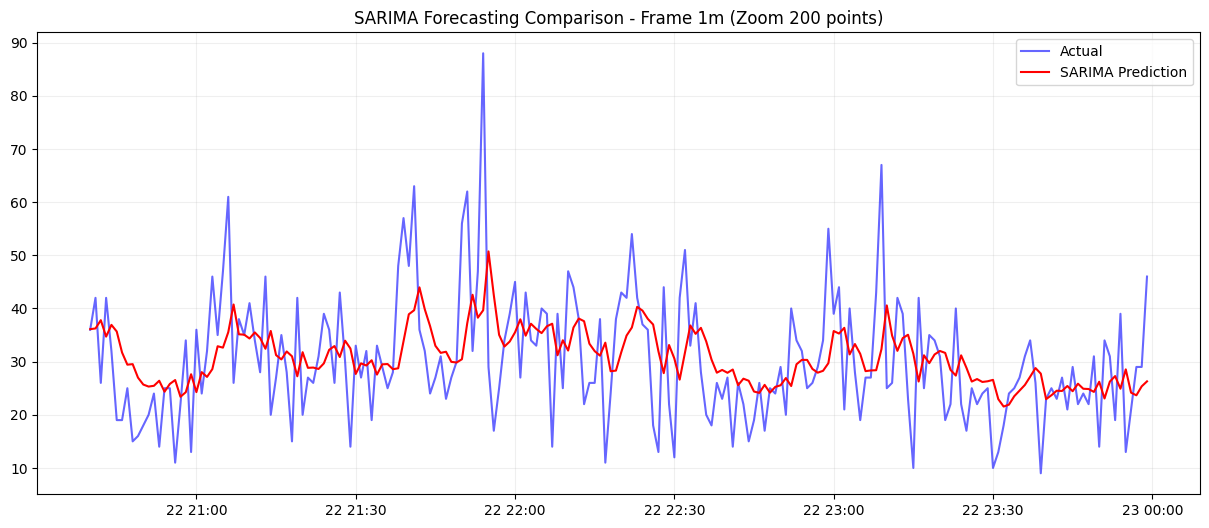

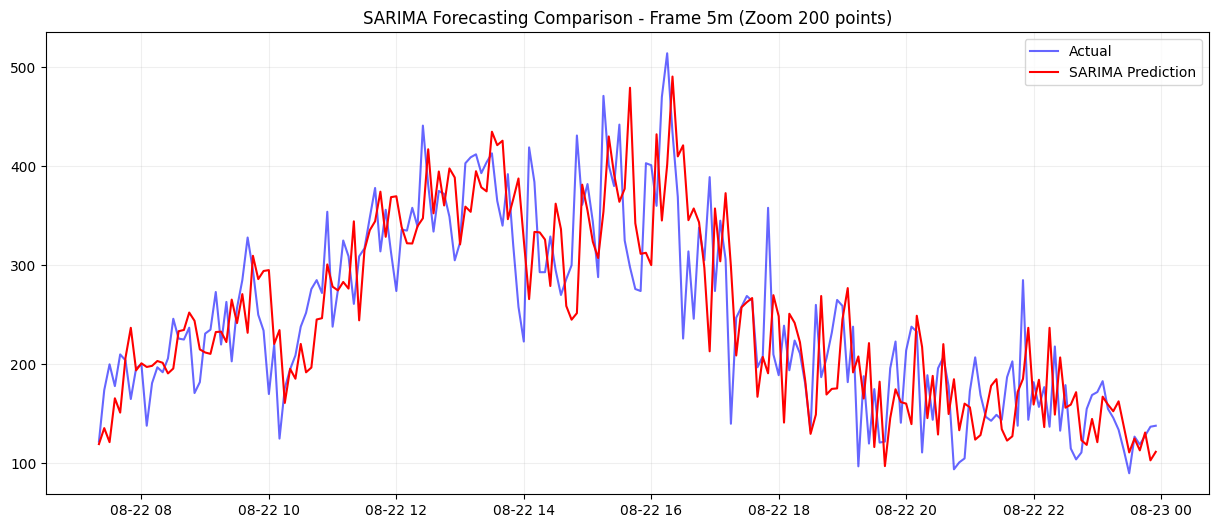

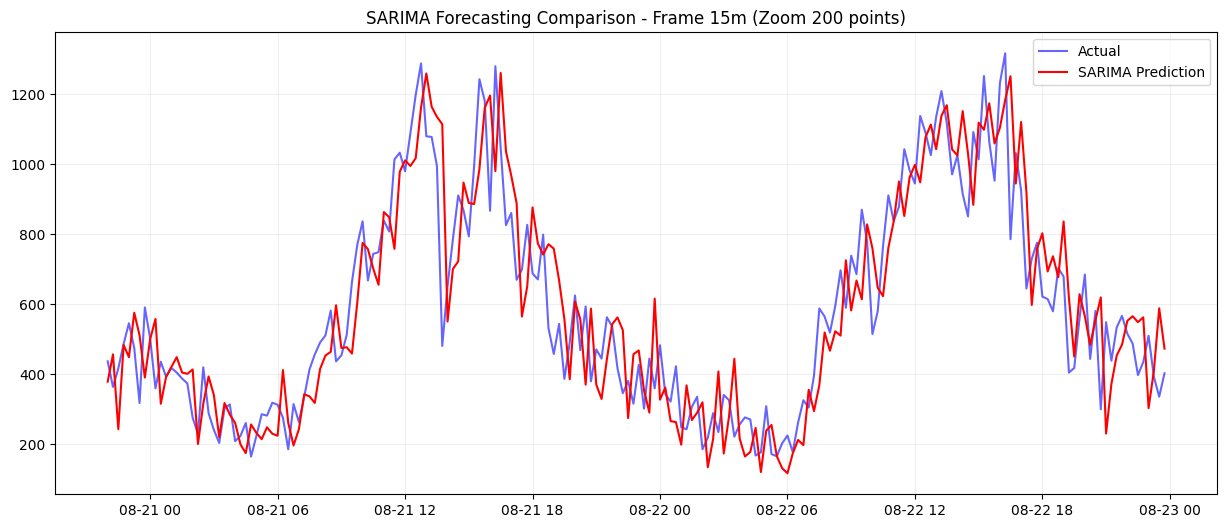

In [52]:
def plot_sarima_results(label, zoom=200):
    actual, pred = results[label]

    plt.figure(figsize=(15, 6))
    # Vẽ thực tế (Blue) và Dự báo (Red)
    plt.plot(actual.index[-zoom:], actual.values[-zoom:], label='Actual', color='blue', alpha=0.6)
    plt.plot(actual.index[-zoom:], pred[-zoom:], label='SARIMA Prediction', color='red', linestyle='-')

    plt.title(f"SARIMA Forecasting Comparison - Frame {label} (Zoom {zoom} points)")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

# Hiển thị 3 biểu đồ
for timeframe in ['1m', '5m', '15m']:
    plot_sarima_results(timeframe)

In [51]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

metrics_data = []

for label, (actual, pred) in results.items():
    
    mse = mean_squared_error(actual, pred)
    
    rmse = np.sqrt(mse)
    
    
    mae = mean_absolute_error(actual, pred)
    
    mask = actual > 0
    if np.sum(mask) > 0:
        mape = np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100
    else:
        mape = 0.0

  
    metrics_data.append({
        'Timeframe': label,
        'RMSE': round(rmse, 2),
        'MSE': round(mse, 2),
        'MAE': round(mae, 2),
        'MAPE (%)': round(mape, 2)
    })


df_metrics = pd.DataFrame(metrics_data)

print("\n" + "="*50)
print("   BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ")
print("="*50)
print(df_metrics.to_string(index=False))



   BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ
Timeframe   RMSE      MSE   MAE  MAPE (%)
       1m  14.37   206.52 10.88     40.23
       5m  53.08  2817.39 39.81     49.35
      15m 126.23 15932.87 94.16     35.85


Prophet

In [73]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
import numpy as np

df_raw = pd.read_csv('/kaggle/input/datasetx/train (1).csv', usecols=['timestamp', 'request_src'], engine='c')

time_format = "%d/%b/%Y:%H:%M:%S %z"
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'], format=time_format, cache=True)
df_raw.set_index('timestamp', inplace=True)

def prepare_data(df, freq):
    res = df['request_src'].resample(freq).count().reset_index()
    res.columns = ['ds', 'y']
    res['ds'] = res['ds'].dt.tz_localize(None)
    return res

df_1m = prepare_data(df_raw, '1min')
df_5m = prepare_data(df_raw, '5min')
df_15m = prepare_data(df_raw, '15min')

print("Data prepared for 1m, 5m, and 15m timeframes.")

Data prepared for 1m, 5m, and 15m timeframes.


17:08:11 - cmdstanpy - INFO - Chain [1] start processing
17:08:14 - cmdstanpy - INFO - Chain [1] done processing


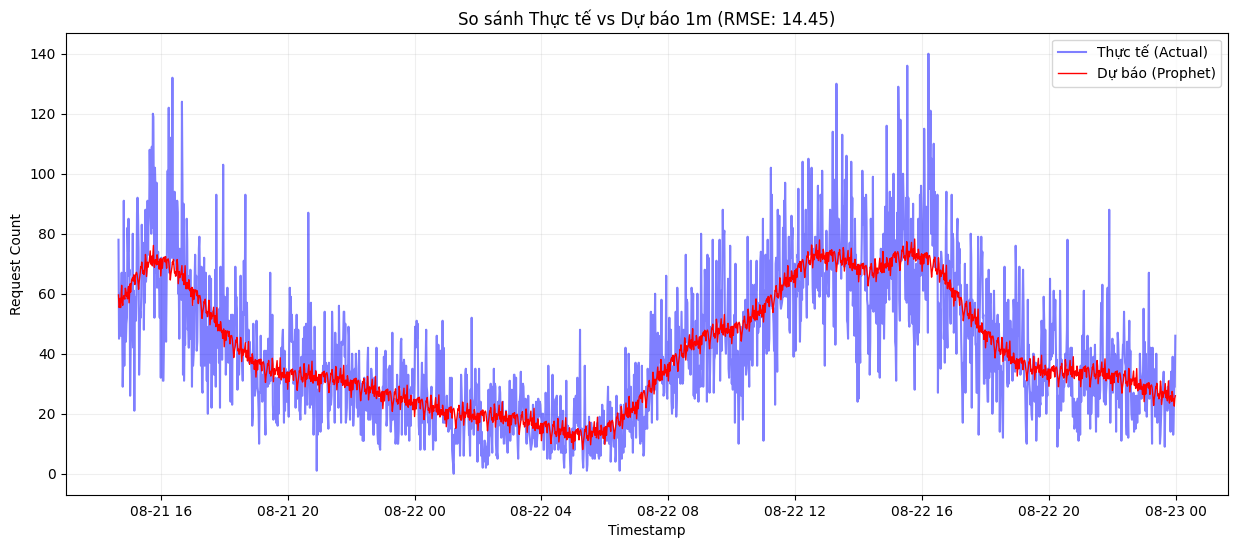

17:08:14 - cmdstanpy - INFO - Chain [1] start processing


17:08:19 - cmdstanpy - INFO - Chain [1] done processing


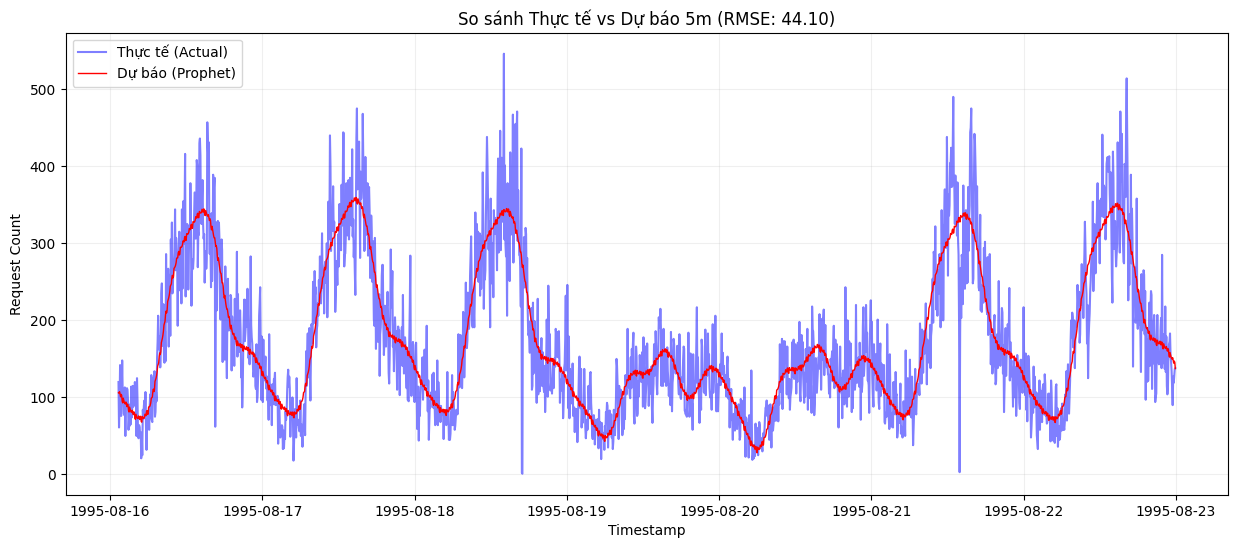

17:08:20 - cmdstanpy - INFO - Chain [1] start processing


17:08:26 - cmdstanpy - INFO - Chain [1] done processing


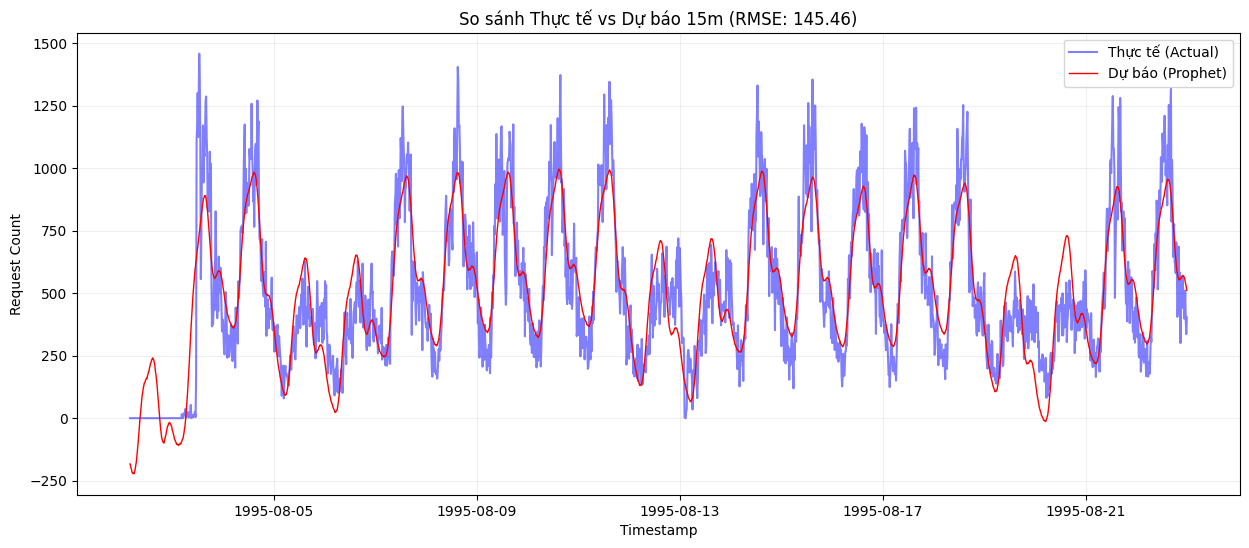




Bảng tổng hợp kết quả:


,Timeframe,RMSE,MSE,MAE,MAPE (%)
0,1m,14.451343,208.841300,10.973698,41.813489
1,5m,44.099582,1944.773117,32.929394,48.848304
2,15m,145.456250,21157.520631,112.691496,79.962777


In [77]:
all_forecasts = {}
metrics_summary = []
datasets = {'1m': df_1m, '5m': df_5m, '15m': df_15m}

for name, df in datasets.items():

    model = Prophet(
        changepoint_prior_scale=0.8,
        n_changepoints=100,
        daily_seasonality=True,
        interval_width=0.95
    )
    model.add_seasonality(name='custom_spike', period=1/24, fourier_order=25)
    train_data = df.tail(2000) 
    model.fit(train_data)
    forecast = model.predict(train_data)
    all_forecasts[name] = (train_data, forecast)

    y_true = train_data['y']
    y_pred = forecast['yhat']

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    metrics_summary.append({
        'Timeframe': name,
        'RMSE': rmse,
        'MSE': mse,
        'MAE': mae,
        'MAPE (%)': mape
    })

    # 3. Plot results
    plot_forecast_results(name, train_data, forecast, rmse)
    print("\n")

# Display overall metrics summary
df_metrics = pd.DataFrame(metrics_summary)
print("\nBảng tổng hợp kết quả:")
display(df_metrics)